In [1]:
from ex_fuzzy.fuzzy_sets import FUZZY_SETS
from ex_fuzzy import eval_tools, utils
from ex_fuzzy.classifiers import FuzzyRulesClassifier as BaseFuzzyRulesClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd

# Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

# Create linguistic variables (fuzzy partitions) from the data
linguistic_variables = utils.construct_partitions(X_train, FUZZY_SETS.t1)

# Create a fuzzy classifier
classifier = BaseFuzzyRulesClassifier(
    nRules=15,                            # Number of rules to evolve
    nAnts=4,                              # Maximum antecedents per rule
    linguistic_variables=linguistic_variables,  # Pre-computed fuzzy variables
    fuzzy_type=FUZZY_SETS.t1,            # Type-1 fuzzy sets
    verbose=True                          # Show training progress
)

# Train the classifier
classifier.fit(X_train, y_train, n_gen=30, pop_size=50)

# Make predictions
y_pred = classifier.predict(X_test)

# Calculate accuracy manually since score method requires X input too
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")

n_gen  |  n_eval  |     f_avg     |     f_min    
     1 |       50 |  0.6124074163 |  0.1297221710
     2 |      100 |  0.4379042511 |  0.1297221710
     3 |      150 |  0.3283235997 |  0.1297221710
     4 |      200 |  0.2777110870 |  0.1297221710
     5 |      250 |  0.2194506716 |  0.1297221710
     6 |      300 |  0.1703782848 |  0.1154598062
     7 |      350 |  0.1280106872 |  0.1154598062
     8 |      400 |  0.1243024724 |  0.1154598062
     9 |      450 |  0.1154598062 |  0.1154598062
    10 |      500 |  0.1153845924 |  0.1116991175
    11 |      550 |  0.1144333056 |  0.0716561513
    12 |      600 |  0.1125307318 |  0.0716561513
    13 |      650 |  0.1093864319 |  0.0716561513
    14 |      700 |  0.0977013815 |  0.0716561513
    15 |      750 |  0.0725507523 |  0.0716561513
    16 |      800 |  0.0716561513 |  0.0716561513
    17 |      850 |  0.0716561513 |  0.0716561513
    18 |      900 |  0.0716561513 |  0.0716561513
    19 |      950 |  0.0716561513 |  0.0716561513


Rules for consequent: 0
----------------
IF sepal length (cm) IS Low AND sepal width (cm) IS Low AND petal width (cm) IS Low WITH DS 0.00279, ACC 1.0
IF sepal width (cm) IS High AND petal length (cm) IS Low WITH DS 0.06472800000000001, ACC 1.0
IF petal length (cm) IS Low AND petal width (cm) IS Low WITH DS 0.0827948, ACC 1.0

Rules for consequent: 1
----------------
IF petal width (cm) IS Medium WITH DS 0.11235, ACC 0.918918918918919

Rules for consequent: 2
----------------
IF petal width (cm) IS High WITH DS 0.09775000000000002, ACC 0.9629629629629629
IF petal length (cm) IS High WITH DS 0.09296315789473686, ACC 1.0




AttributeError: 'dict' object has no attribute 'path'

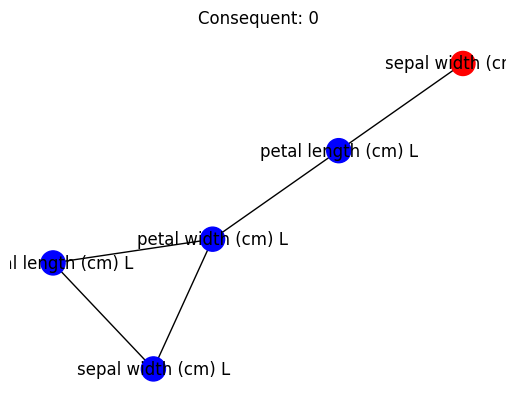

In [8]:
from ex_fuzzy.vis_rules import visualize_rulebase
classifier.fl_classifier2.explainable_predict(X_test,out_class_names=True)
classifier.internal_classifier().print_rules()
visualize_rulebase(classifier.fl_classifier2.rule_base,export_path="/home/asier/")